In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'tidak ada GPU')

True
Tesla T4


In [12]:
from google.colab import drive
import zipfile, os, shutil, pandas as pd

drive.mount('/content/drive')

ZIP_PATH = '/content/drive/MyDrive/transfer learning/dataset_raw.zip'
DATA_DIR = '/content/data'

shutil.rmtree(DATA_DIR, ignore_errors=True)
os.makedirs(DATA_DIR)
with zipfile.ZipFile(ZIP_PATH) as z:
    z.extractall(DATA_DIR)

meta = pd.read_csv(os.path.join(DATA_DIR, 'metadata.csv'))
print(meta.shape)
print(pd.crosstab(meta['kelas'], meta['split']))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(359, 14)
split        test  train  val
kelas                        
huruf_angka    51    100   29
panah          32     95   52


In [13]:
import os, time, copy, random
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

DATA_DIR = '/content/data'
OUT_DIR  = '/content/drive/MyDrive/transfer learning/hasil'
IMG_SIZE = 224
BATCH    = 32
EPOCHS   = 10
SEED     = 42
UNFREEZE_FROM = 13
MODES = ['feature_extraction', 'fine_tune_sebagian', 'fine_tune_penuh']
LR_HEAD = {'feature_extraction': 1e-3, 'fine_tune_sebagian': 1e-3, 'fine_tune_penuh': 1e-3}
LR_BACKBONE = {'feature_extraction': 0, 'fine_tune_sebagian': 3e-4, 'fine_tune_penuh': 1e-4}

os.makedirs(OUT_DIR, exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [14]:
meta = pd.read_csv(os.path.join(DATA_DIR, 'metadata.csv'))
CLASSES = sorted(meta['kelas'].unique())
C2I = {c: i for i, c in enumerate(CLASSES)}
print('Kelas:', C2I)

norm = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
tf_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ColorJitter(0.3, 0.3, 0.2),
    transforms.ToTensor(), norm])
tf_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(), norm])

class ImgDS(Dataset):
    def __init__(self, df, tf):
        self.df = df.reset_index(drop=True); self.tf = tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(os.path.join(DATA_DIR, r['kelas'], r['nama_file'])).convert('RGB')
        return self.tf(img), C2I[r['kelas']]

df_tr = meta[meta['split'] == 'train']
df_va = meta[meta['split'] == 'val']
df_te = meta[meta['split'] == 'test']
mk = lambda df, tf, sh: DataLoader(ImgDS(df, tf), batch_size=BATCH, shuffle=sh, num_workers=2, pin_memory=True)
dl_tr, dl_va, dl_te = mk(df_tr, tf_train, True), mk(df_va, tf_eval, False), mk(df_te, tf_eval, False)

cnt = df_tr['kelas'].value_counts()
cw = torch.tensor([len(df_tr) / (len(CLASSES) * cnt[c]) for c in CLASSES], dtype=torch.float32).to(device)
print('Class weight:', dict(zip(CLASSES, cw.tolist())))
criterion = nn.CrossEntropyLoss(weight=cw)

x, y = next(iter(dl_tr))
print('Ukuran batch:', x.shape, y.shape)
print('Jumlah train/val/test:', len(df_tr), len(df_va), len(df_te))

Kelas: {'huruf_angka': 0, 'panah': 1}
Class weight: {'huruf_angka': 0.9750000238418579, 'panah': 1.0263158082962036}
Ukuran batch: torch.Size([32, 3, 224, 224]) torch.Size([32])
Jumlah train/val/test: 195 81 83


In [15]:
def build_model(mode):
    m = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)
    m.classifier[3] = nn.Linear(m.classifier[3].in_features, len(CLASSES))
    for p in m.parameters(): p.requires_grad = False
    for p in m.classifier.parameters(): p.requires_grad = True
    if mode == 'feature_extraction':
        frozen = list(m.features)
    elif mode == 'fine_tune_sebagian':
        for p in m.features[UNFREEZE_FROM:].parameters(): p.requires_grad = True
        frozen = list(m.features[:UNFREEZE_FROM])
    else:
        for p in m.parameters(): p.requires_grad = True
        frozen = []
    return m.to(device), frozen

@torch.no_grad()
def evaluate(model, dl):
    model.eval(); tot, ls, P, Y = 0, 0.0, [], []
    for x, y in dl:
        x, y = x.to(device), y.to(device)
        out = model(x)
        ls += criterion(out, y).item() * len(y); tot += len(y)
        P += out.argmax(1).cpu().tolist(); Y += y.cpu().tolist()
    return ls / tot, accuracy_score(Y, P), f1_score(Y, P, average='macro'), P, Y

for mode in MODES:
    m, _ = build_model(mode)
    n = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'{mode:20s} parameter yang dilatih: {n:,}')

feature_extraction   parameter yang dilatih: 1,232,642
fine_tune_sebagian   parameter yang dilatih: 3,412,106
fine_tune_penuh      parameter yang dilatih: 4,204,594



===== MODE: feature_extraction =====
Epoch  1/10 | train loss 0.6584 acc 0.6154 | val loss 0.4048 acc 0.7407 f1 0.6322
Epoch  2/10 | train loss 0.4874 acc 0.7333 | val loss 0.4310 acc 0.7407 f1 0.6995
Epoch  3/10 | train loss 0.3335 acc 0.8205 | val loss 0.3292 acc 0.8272 f1 0.7816
Epoch  4/10 | train loss 0.4086 acc 0.8256 | val loss 0.2930 acc 0.8272 f1 0.7816
Epoch  5/10 | train loss 0.3209 acc 0.8256 | val loss 0.5080 acc 0.6420 f1 0.6400
Epoch  6/10 | train loss 0.2522 acc 0.8821 | val loss 0.2071 acc 0.9136 f1 0.8998
Epoch  7/10 | train loss 0.1936 acc 0.9179 | val loss 0.2739 acc 0.8395 f1 0.8370
Epoch  8/10 | train loss 0.1937 acc 0.9231 | val loss 0.2134 acc 0.8889 f1 0.8683
Epoch  9/10 | train loss 0.1643 acc 0.9282 | val loss 0.2487 acc 0.8519 f1 0.8491
Epoch 10/10 | train loss 0.1774 acc 0.9282 | val loss 0.1470 acc 0.9259 f1 0.9150
              precision    recall  f1-score   support

 huruf_angka     1.0000    0.9804    0.9901        51
       panah     0.9697    1.0000

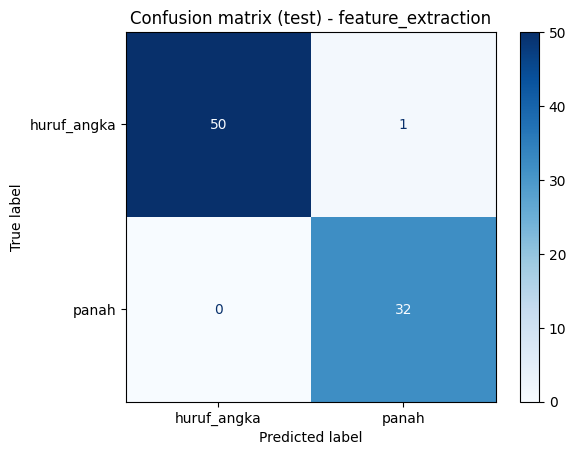

In [16]:
def run_mode(mode):
    print(f'\n===== MODE: {mode} =====')
    model, frozen = build_model(mode)
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    head = list(model.classifier.parameters())
    head_ids = {id(p) for p in head}
    bb = [p for p in model.parameters() if p.requires_grad and id(p) not in head_ids]
    groups = [{'params': head, 'lr': LR_HEAD[mode]}]
    if bb: groups.append({'params': bb, 'lr': LR_BACKBONE[mode]})
    opt = torch.optim.AdamW(groups, weight_decay=1e-4)

    hist = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': [], 'val_f1': []}
    best_f1, best_state, t0 = -1, None, time.time()
    for ep in range(1, EPOCHS + 1):
        model.train()
        for blk in frozen: blk.eval()
        tot, ls, ok = 0, 0.0, 0
        for x, y in dl_tr:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x); loss = criterion(out, y)
            loss.backward(); opt.step()
            ls += loss.item() * len(y); tot += len(y); ok += (out.argmax(1) == y).sum().item()
        vl, va, vf, _, _ = evaluate(model, dl_va)
        hist['train_loss'].append(ls / tot); hist['train_acc'].append(ok / tot)
        hist['val_loss'].append(vl); hist['val_acc'].append(va); hist['val_f1'].append(vf)
        print(f'Epoch {ep:2d}/{EPOCHS} | train loss {ls/tot:.4f} acc {ok/tot:.4f} | val loss {vl:.4f} acc {va:.4f} f1 {vf:.4f}')
        if vf > best_f1:
            best_f1, best_state = vf, copy.deepcopy(model.state_dict())
    train_time = time.time() - t0

    model.load_state_dict(best_state)
    torch.save(best_state, os.path.join(OUT_DIR, f'model_{mode}.pth'))
    _, ta, tf1, P, Y = evaluate(model, dl_te)
    f1_per = f1_score(Y, P, average=None)
    print(classification_report(Y, P, target_names=CLASSES, digits=4))
    cm = confusion_matrix(Y, P)
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(cmap='Blues')
    plt.title(f'Confusion matrix (test) - {mode}')
    plt.savefig(os.path.join(OUT_DIR, f'cm_{mode}.png'), dpi=150, bbox_inches='tight'); plt.show()

    row = {'mode': mode, 'param_dilatih': n_train, 'best_val_f1': round(best_f1, 4),
           'best_val_acc': round(max(hist['val_acc']), 4),
           'test_acc': round(ta, 4), 'test_macro_f1': round(tf1, 4),
           f'test_f1_{CLASSES[0]}': round(f1_per[0], 4), f'test_f1_{CLASSES[1]}': round(f1_per[1], 4),
           'waktu_train_detik': round(train_time, 1)}
    return row, hist, model

rows, hists, models_out = [], {}, {}

r, h, mdl = run_mode('feature_extraction')
rows.append(r); hists['feature_extraction'] = h; models_out['feature_extraction'] = mdl


===== MODE: fine_tune_sebagian =====
Epoch  1/10 | train loss 0.5209 acc 0.7077 | val loss 0.5008 acc 0.7037 f1 0.7037
Epoch  2/10 | train loss 0.2982 acc 0.8872 | val loss 0.1640 acc 0.9506 f1 0.9444
Epoch  3/10 | train loss 0.2835 acc 0.8667 | val loss 0.2413 acc 0.9630 f1 0.9587
Epoch  4/10 | train loss 0.2135 acc 0.8872 | val loss 0.0803 acc 0.9506 f1 0.9444
Epoch  5/10 | train loss 0.2839 acc 0.9026 | val loss 0.1076 acc 0.9630 f1 0.9600
Epoch  6/10 | train loss 0.1791 acc 0.9231 | val loss 0.0616 acc 0.9877 f1 0.9865
Epoch  7/10 | train loss 0.1008 acc 0.9385 | val loss 0.0631 acc 0.9877 f1 0.9865
Epoch  8/10 | train loss 0.1190 acc 0.9538 | val loss 0.2564 acc 0.9012 f1 0.8967
Epoch  9/10 | train loss 0.2699 acc 0.9385 | val loss 1.0371 acc 0.5556 f1 0.5438
Epoch 10/10 | train loss 0.0755 acc 0.9795 | val loss 0.0300 acc 1.0000 f1 1.0000
              precision    recall  f1-score   support

 huruf_angka     1.0000    1.0000    1.0000        51
       panah     1.0000    1.0000

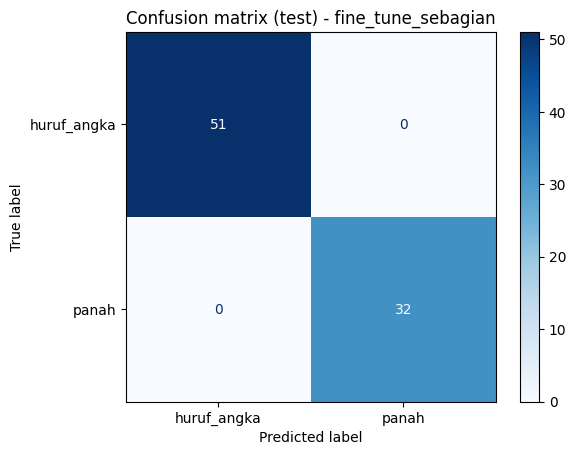


===== MODE: fine_tune_penuh =====
Epoch  1/10 | train loss 0.6467 acc 0.6513 | val loss 0.4993 acc 0.7901 f1 0.7224
Epoch  2/10 | train loss 0.4100 acc 0.8154 | val loss 0.3014 acc 0.8395 f1 0.8359
Epoch  3/10 | train loss 0.3285 acc 0.8256 | val loss 0.3150 acc 0.8148 f1 0.7626
Epoch  4/10 | train loss 0.4078 acc 0.7949 | val loss 0.3097 acc 0.8025 f1 0.7429
Epoch  5/10 | train loss 0.2193 acc 0.9128 | val loss 0.1105 acc 0.9877 f1 0.9865
Epoch  6/10 | train loss 0.1680 acc 0.9333 | val loss 0.2087 acc 0.9136 f1 0.8998
Epoch  7/10 | train loss 0.1505 acc 0.9333 | val loss 0.0957 acc 0.9877 f1 0.9865
Epoch  8/10 | train loss 0.0947 acc 0.9795 | val loss 0.0851 acc 0.9753 f1 0.9727
Epoch  9/10 | train loss 0.1095 acc 0.9692 | val loss 0.1459 acc 0.9383 f1 0.9299
Epoch 10/10 | train loss 0.0964 acc 0.9487 | val loss 0.0732 acc 0.9506 f1 0.9444
              precision    recall  f1-score   support

 huruf_angka     1.0000    1.0000    1.0000        51
       panah     1.0000    1.0000   

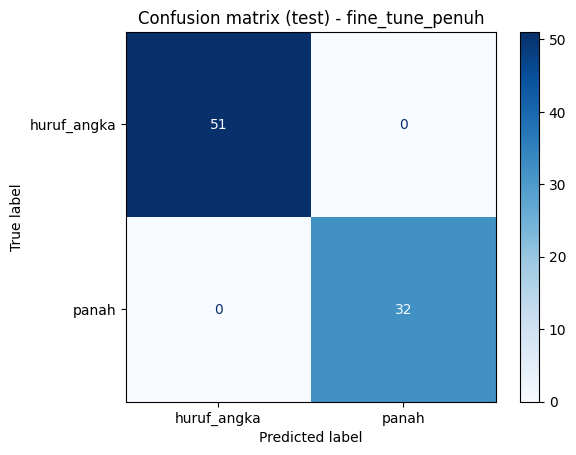

In [17]:
for m in ['fine_tune_sebagian', 'fine_tune_penuh']:
    r, h, mdl = run_mode(m)
    rows.append(r); hists[m] = h; models_out[m] = mdl

              mode  param_dilatih  best_val_f1  best_val_acc  test_acc  test_macro_f1  test_f1_huruf_angka  test_f1_panah  waktu_train_detik
feature_extraction        1232642       0.9150        0.9259     0.988         0.9874               0.9901         0.9846               19.4
fine_tune_sebagian        3412106       1.0000        1.0000     1.000         1.0000               1.0000         1.0000               18.1
   fine_tune_penuh        4204594       0.9865        0.9877     1.000         1.0000               1.0000         1.0000               21.2


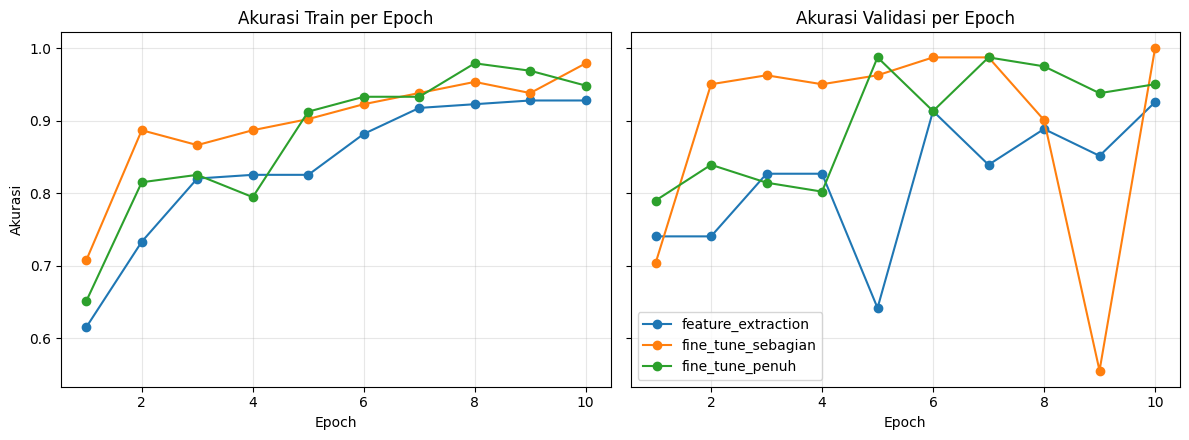

In [18]:
res = pd.DataFrame(rows)
res.to_csv(os.path.join(OUT_DIR, 'hasil_3_mode.csv'), index=False)
print(res.to_string(index=False))

ep = range(1, EPOCHS + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for m in MODES:
    ax[0].plot(ep, hists[m]['train_acc'], marker='o', label=m)
    ax[1].plot(ep, hists[m]['val_acc'], marker='o', label=m)
ax[0].set_title('Akurasi Train per Epoch'); ax[1].set_title('Akurasi Validasi per Epoch')
for a in ax: a.set_xlabel('Epoch'); a.grid(alpha=.3)
ax[0].set_ylabel('Akurasi'); ax[1].legend()
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'akurasi_per_epoch.png'), dpi=150); plt.show()

In [19]:
best_mode = res.sort_values('best_val_f1', ascending=False).iloc[0]['mode']
print('Mode terpilih:', best_mode)

@torch.no_grad()
def latency(model, dev, n=100, warm=20):
    model = model.to(dev).eval()
    x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=dev)
    for _ in range(warm): model(x)
    if dev.type == 'cuda': torch.cuda.synchronize()
    ts = []
    for _ in range(n):
        t = time.perf_counter(); model(x)
        if dev.type == 'cuda': torch.cuda.synchronize()
        ts.append((time.perf_counter() - t) * 1000)
    return np.mean(ts), np.std(ts)

lat = {}
if torch.cuda.is_available():
    lat['GPU'] = latency(models_out[best_mode], torch.device('cuda'))
lat['CPU'] = latency(models_out[best_mode], torch.device('cpu'))
lat_df = pd.DataFrame([{'perangkat': k, 'latensi_ms_mean': round(v[0], 2), 'latensi_ms_std': round(v[1], 2)} for k, v in lat.items()])
lat_df.insert(0, 'mode', best_mode)
lat_df.to_csv(os.path.join(OUT_DIR, 'latensi.csv'), index=False)
print(lat_df.to_string(index=False))

Mode terpilih: fine_tune_sebagian
              mode perangkat  latensi_ms_mean  latensi_ms_std
fine_tune_sebagian       GPU             6.67            0.92
fine_tune_sebagian       CPU            21.13            2.39


In [20]:
import shutil, os
from google.colab import files

REPO = '/content/repo'
shutil.rmtree(REPO, ignore_errors=True)
os.makedirs(REPO)

# 1. dataset_raw (folder kelas + metadata.csv + ringkasan_data.txt)
shutil.copytree('/content/data', f'{REPO}/dataset_raw')

# 2. hasil: tabel 3 mode, grafik, confusion matrix, latensi
os.makedirs(f'{REPO}/hasil')
for f in ['hasil_3_mode.csv', 'akurasi_per_epoch.png', 'latensi.csv'] + [f'cm_{m}.png' for m in MODES]:
    shutil.copy(os.path.join(OUT_DIR, f), f'{REPO}/hasil/{f}')

# 3. model terpilih saja
os.makedirs(f'{REPO}/model')
shutil.copy(os.path.join(OUT_DIR, f'model_{best_mode}.pth'), f'{REPO}/model/')

# cek isi
for root, dirs, fs in os.walk(REPO):
    depth = root.count(os.sep) - REPO.count(os.sep)
    if depth <= 1:
        print('  ' * depth + os.path.basename(root) + '/', f'({len(fs)} file)')

# zip + backup ke Drive + unduh
zip_path = shutil.make_archive('/content/repo_transfer_learning', 'zip', REPO)
shutil.copy(zip_path, os.path.join(OUT_DIR, 'repo_transfer_learning.zip'))
print('Ukuran zip: %.1f MB' % (os.path.getsize(zip_path) / 1e6))
files.download(zip_path)

repo/ (0 file)
  dataset_raw/ (2 file)
  model/ (1 file)
  hasil/ (6 file)
Ukuran zip: 22.2 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
g = meta.groupby('session_id')['split'].nunique()
print('session_id yang muncul di >1 split:', (g > 1).sum())
print(meta['kelas'].value_counts())
print(pd.crosstab(meta['kelas'], meta['kondisi_cahaya']))


session_id yang muncul di >1 split: 0
kelas
huruf_angka    180
panah          179
Name: count, dtype: int64
kondisi_cahaya  gelap  redup  terang
kelas                               
huruf_angka         3     43     134
panah               3     41     135
